# Week 02 — Exploratory Data Analysis

## Business Problem (continued)

We have a dataset from a fictional mobile telephone provider, which includes various features relating to accounts held - e.g. the number of mins of calls used, total charges etc.  Also inlcuded in this data is a 'Churn Label' which tells us whether a customer left the provider (i.e. closed their account).  

In addition to the original synthetic_churn dataset, another dataset has been identified that may give the reason for the churn: churn_reason_csv.

Let's join the two datasets and explore further.

In [1]:
# Import packages
from pathlib import Path

import pandas as pd
print("pandas:", pd.__version__)

import numpy as np
print("numpy:", np.__version__)

import seaborn as sns
print("seaborn:", sns.__version__)

import matplotlib.pyplot as plt

import sweetviz as sv
print("sweetviz:", sv.__version__)

print("Imports successful")

pandas: 3.0.3
numpy: 2.4.6
seaborn: 0.13.2
sweetviz: 2.3.3
Imports successful


In [2]:
# setup paths

PROJECT_DIR = Path(r"C:\Users\serba\ds_projects\bpp_lectures")
COURSE_DOCS = Path(r"C:\Users\serba\OneDrive\BPP_DS")

DATA_DIR = PROJECT_DIR / "data"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

DATA_DIR.mkdir(exist_ok=True)
NOTEBOOK_DIR.mkdir(exist_ok=True)

PROJECT_DIR, COURSE_DOCS, DATA_DIR

(WindowsPath('C:/Users/serba/ds_projects/bpp_lectures'),
 WindowsPath('C:/Users/serba/OneDrive/BPP_DS'),
 WindowsPath('C:/Users/serba/ds_projects/bpp_lectures/data'))

In [4]:
# read in sythetic_churn data
data_path = Path("../data/synthetic_churn.csv")
df_churn = pd.read_csv(data_path)
# read in churn)reason data
data_path2 = Path("../data/churn_reason_csv.csv")
df_reason = pd.read_csv(data_path2)

## Explore Churn Reason data

Before joining, let's explore the new dataset a little further.


In [7]:
print("Original churn dataset shape:  ", df_churn.shape)
print("New churn reason shape:  ", df_reason.shape)

Original churn dataset shape:   (6688, 27)
New churn reason shape:   (1769, 3)


Clearly the two datasets are different shapes.  Our new dataset has approximately a quarter of the number of rows as the original churn dataset.  However, this is likely correct - our previous EDA revealed that 1796 customers had left, and we seem to have churn reasons for 1769 of these, so this seems about right.  

Once joined we should expect to have 27 churn customers that do not have a reason attached.

Let's have a look at the column info:

In [9]:
df_reason.info()

<class 'pandas.DataFrame'>
RangeIndex: 1769 entries, 0 to 1768
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     1769 non-null   str  
 1   ChurnCategory  1769 non-null   str  
 2   ChurnReason    1769 non-null   str  
dtypes: str(3)
memory usage: 41.6 KB


In [11]:
df_reason.head()

,customerID,ChurnCategory,ChurnReason
0,9998-HXKO,Competitor,Competitor made better offer
1,4441-WTBT,Competitor,Competitor made better offer
2,7160-LCLC,Other,Moved
3,3404-PVOS,Competitor,Competitor made better offer
4,5053-TIAA,Competitor,Competitor had better devices


It seems that our data set has only three string variables:
* customerID - this appears to be a unique key that could be used to join (let's test this to be sure)
* ChurnCategory - which categorises the churn reason and which may be sueful for visualisation purposes
* ChurnReason - this gives a description of why they left

First, let's explore customerID:

In [12]:
sum(df_reason.duplicated(['customerID']))

0

Perfect, the customerID column is in fact unique.  This makes it a suitable primary key for our join.

For efficiency purposes, let's sort our dataset on this unique key:

In [13]:
df_reason = df_reason.sort_values(by="customerID")
print(df_reason.head())

     customerID    ChurnCategory                    ChurnReason
1724  0000-XZWZ  Dissatisfaction        Service dissatisfaction
773   0003-PKVZ  Dissatisfaction        Service dissatisfaction
1477  0023-JOAG  Dissatisfaction        Product dissatisfaction
775   0028-OJTA       Competitor  Competitor had better devices
231   0034-TMPR       Competitor   Competitor offered more data


In [15]:
# repeat for the original datset
df_churn = df_churn.sort_values(by="Customer ID")
print(df_churn.head())

     Customer ID Churn Label  Account Length (in months)  Local Calls  \
6643   0000-XZWZ         Yes                           1            2   
1281   0001-NBTF          No                          67          201   
5920   0001-QFCV          No                          74          181   
1924   0002-UBRG          No                          15           34   
4267   0003-PKVZ         Yes                          38          215   

      Local Mins  Intl Calls  Intl Mins Intl Active Intl Plan  \
6643         4.0         4.0       12.1         Yes        no   
1281       534.3         0.0        0.0          No        no   
5920       592.9         0.0        0.0          No        no   
1924        91.8         0.0        0.0          No        no   
4267       562.7       114.0      410.4         Yes        no   

      Extra International Charges  ...  Age  Under 30 Senior  Group  \
6643                          4.0  ...   50        No     No    Yes   
1281                        

In [16]:
# quick check for duplicated rows
sum(df_reason.duplicated())

0

In [ ]:
# How many uniqie values in ChurnCategory?
df_reason['ChurnCategory'].nunique()

5

In [ ]:
# and in ChurnReason?
df_reason['ChurnReason'].nunique()

20

## Explore variables

OK, we have two string variables that can be joined onto our original dataset but we don't know a great deal about them...yet.

Let's explore further:

In [20]:
df_reason['ChurnCategory'].value_counts()

ChurnCategory
Competitor         805
Attitude           287
Dissatisfaction    286
Price              200
Other              191
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='ChurnCategory'>

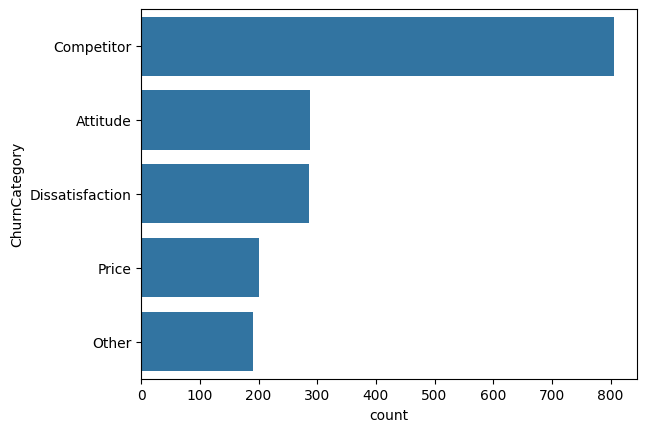

In [22]:
sns.countplot(
    data=df_reason,
    y='ChurnCategory',
    order=df_reason['ChurnCategory'].value_counts().index
)

In [23]:
df_reason['ChurnReason'].value_counts()

ChurnReason
Competitor made better offer                 303
Competitor had better devices                297
Attitude of support person                   203
Don't know                                   123
Competitor offered more data                 110
Competitor offered higher download speeds     95
Attitude of service provider                  84
Price too high                                74
Product dissatisfaction                       73
Network reliability                           69
Long distance charges                         61
Service dissatisfaction                       60
Moved                                         44
Extra data charges                            37
Limited range of services                     35
Poor expertise of online support              30
Lack of affordable download/upload speed      28
Lack of self-service on Website               26
Poor expertise of phone support               11
Deceased                                       6
Name: co

<Axes: ylabel='ChurnReason'>

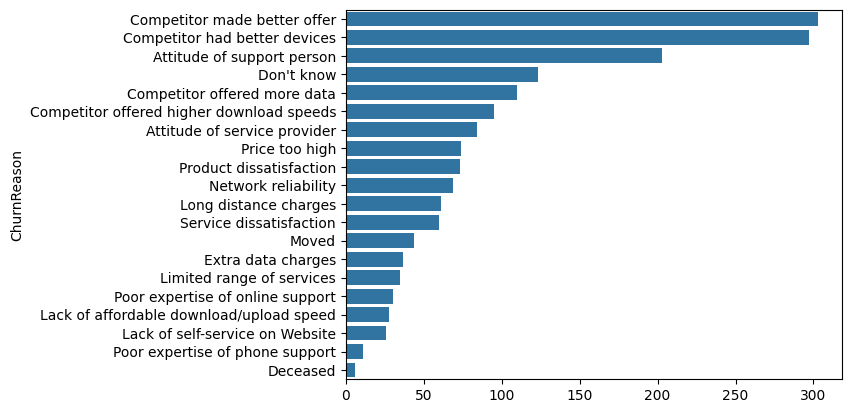

In [ ]:
reason_counts = df_reason['ChurnReason'].value_counts()#.head(10)

sns.barplot(
    x=reason_counts.values,
    y=reason_counts.index
)

<Axes: xlabel='ChurnCategory', ylabel='ChurnReason'>

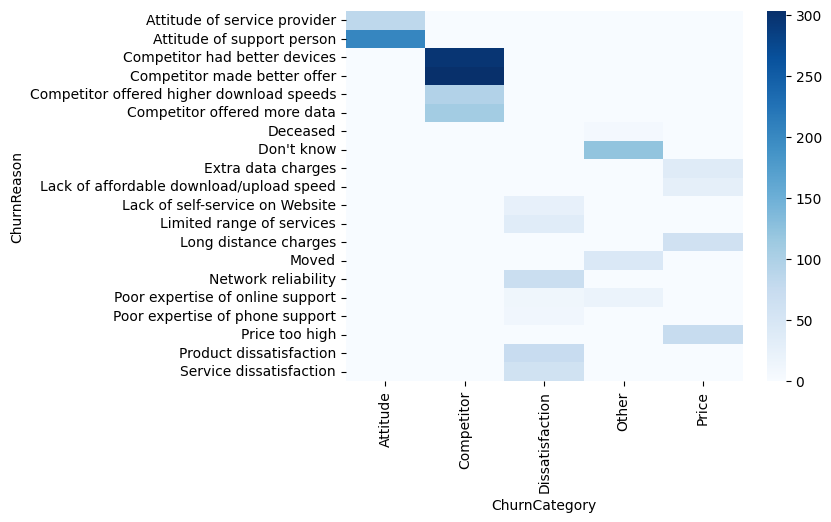

In [27]:
ct = pd.crosstab(
    df_reason['ChurnReason'],
    df_reason['ChurnCategory']
)

sns.heatmap(
    ct,
    cmap='Blues'
)

<Axes: xlabel='ChurnCategory', ylabel='ChurnReason'>

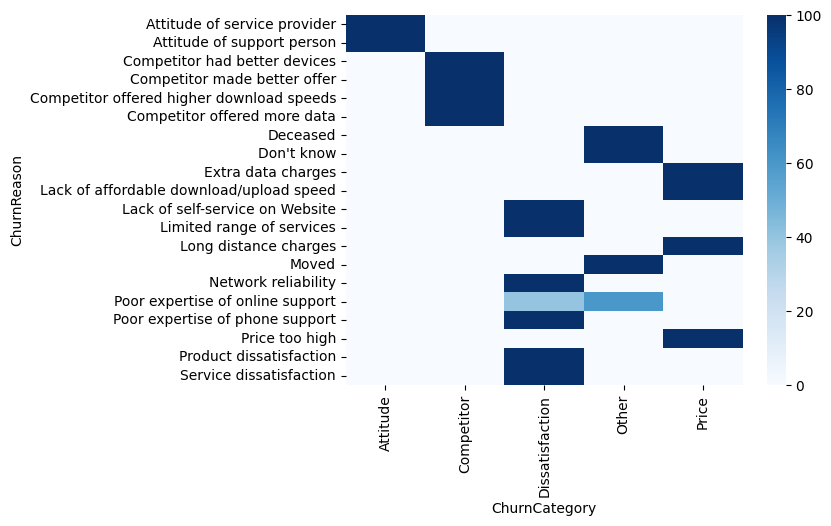

In [29]:
ct_pct = pd.crosstab(
    df_reason['ChurnReason'],
    df_reason['ChurnCategory'],
    normalize='index'
) * 100

sns.heatmap(
    ct_pct,
    cmap='Blues'
)


In [31]:
flows = (
    df_reason.groupby(['ChurnCategory', 'ChurnReason'])
      .size()
      .reset_index(name='count')
)

In [32]:
all_nodes = (
    list(flows['ChurnCategory'].unique()) +
    list(flows['ChurnReason'].unique())
)

node_dict = {
    node: i
    for i, node in enumerate(all_nodes)
}

In [36]:
import plotly.graph_objects as go

fig = go.Figure(
    go.Sankey(
        node=dict(
            label=all_nodes
        ),
        link=dict(
            source=flows['ChurnCategory'].map(node_dict),
            target=flows['ChurnReason'].map(node_dict),
            value=flows['count']
        )
    )
)

fig.update_layout(
    title_text="Churn Categories to Churn Reasons",
    font_size=10
)

fig.show()